# Test Artifact Analysis

Analyze the artifacts written by `test_agent.py`. The notebook loads old and new artifact schemas, compares final test score against configuration and fitness-shaping values, and uses DBSCAN to look for behavior/configuration patterns.

## 1. Load Artifacts

Run this from either the repository root or the `AS4_space-miner` folder.

In [1]:
from pathlib import Path
import configparser
import json
import math
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

cwd = Path.cwd()
if (cwd / "artifacts").exists():
    PROJECT_DIR = cwd
elif (cwd / "AS4_space-miner" / "artifacts").exists():
    PROJECT_DIR = cwd / "AS4_space-miner"
else:
    raise FileNotFoundError("Could not find the AS4_space-miner/artifacts folder")

ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
print(f"Project directory: {PROJECT_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")

Project directory: c:\Users\Shira\NTUST\Soft-Computing\AS4_space-miner
Artifacts directory: c:\Users\Shira\NTUST\Soft-Computing\AS4_space-miner\artifacts


In [2]:
def parse_scalar(value):
    value = str(value).strip()
    if value.lower() in {"true", "false"}:
        return value.lower() == "true"
    try:
        parsed = float(value)
    except ValueError:
        return value
    if parsed.is_integer():
        return int(parsed)
    return parsed


def flatten(prefix, value, output):
    if isinstance(value, dict):
        for key, nested in value.items():
            next_prefix = f"{prefix}.{key}" if prefix else str(key)
            flatten(next_prefix, nested, output)
    elif isinstance(value, (list, tuple)):
        output[prefix] = tuple(value)
    else:
        output[prefix] = value


def parse_config_artifact(path):
    if not path.exists():
        return {}
    parser = configparser.ConfigParser(strict=False)
    parser.optionxform = str
    parser.read(path, encoding="utf-8")
    values = {}
    for section in parser.sections():
        for key, value in parser.items(section):
            values[f"artifact_config.{section}.{key.strip()}"] = parse_scalar(value)
    return values


def load_payload(test_dir):
    pkl_path = test_dir / f"{test_dir.name}.pkl"
    json_path = test_dir / "game_results.json"
    if pkl_path.exists():
        try:
            with pkl_path.open("rb") as handle:
                return pickle.load(handle), "pkl"
        except Exception as exc:
            warnings.warn(f"Could not read {pkl_path.name}: {exc}; trying JSON")
    if json_path.exists():
        with json_path.open("r", encoding="utf-8") as handle:
            return json.load(handle), "json"
    return None, None


def test_number(test_dir):
    try:
        return int(test_dir.name.split("_", 1)[1])
    except (IndexError, ValueError):
        return math.inf


rows = []
for test_dir in sorted(ARTIFACTS_DIR.glob("test_*"), key=test_number):
    if not test_dir.is_dir():
        continue
    payload, source = load_payload(test_dir)
    if payload is None:
        continue

    row = {
        "artifact_dir": test_dir.name,
        "artifact_source": source,
        "analysis_schema_version": payload.get("analysis_schema_version", 1),
        "test_number": payload.get("test_number", test_number(test_dir)),
        "created_at": payload.get("created_at"),
        "config_file": payload.get("config_file"),
        "genome_path": payload.get("genome_path"),
    }
    row.update(parse_config_artifact(test_dir / "configuration.txt"))
    flatten("result", payload.get("results", {}), row)
    flatten("logged_config", payload.get("config_values", {}), row)
    flatten("training", payload.get("training_constants", {}), row)
    flatten("winner", payload.get("winner_summary", {}), row)
    flatten("behavior", payload.get("behavior_summary", {}), row)
    rows.append(row)

df = pd.DataFrame(rows).sort_values("test_number").reset_index(drop=True)
print(f"Loaded {len(df)} runs")
df.head()

Loaded 80 runs


,artifact_dir,artifact_source,analysis_schema_version,test_number,created_at,config_file,genome_path,artifact_config.NEAT.fitness_criterion,artifact_config.NEAT.fitness_threshold,artifact_config.NEAT.pop_size,...,behavior.input_stats.asteroid_relative_velocity_x.count,behavior.input_stats.asteroid_relative_velocity_x.mean,behavior.input_stats.asteroid_relative_velocity_x.std,behavior.input_stats.asteroid_relative_velocity_x.min,behavior.input_stats.asteroid_relative_velocity_x.max,behavior.input_stats.asteroid_relative_velocity_y.count,behavior.input_stats.asteroid_relative_velocity_y.mean,behavior.input_stats.asteroid_relative_velocity_y.std,behavior.input_stats.asteroid_relative_velocity_y.min,behavior.input_stats.asteroid_relative_velocity_y.max
0,test_1,pkl,1,1,2026-06-03T17:41:10,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,max,10000,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test_59,json,1,1,2026-06-05T17:51:39,C:\Users\user\Desktop\soft hw4\neat_config.txt,C:\Users\user\Desktop\soft hw4\winner.pkl,max,10000,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,test_2,pkl,1,2,2026-06-03T17:52:48,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,max,10000,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,test_3,pkl,1,3,2026-06-05T08:31:05,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,max,10000,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,test_4,pkl,1,4,2026-06-05T08:36:58,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,C:\Users\Shira\NTUST\Soft-Computing\AS4_space-...,max,10000,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Quality and Score Overview

In [3]:
if df.empty:
    raise RuntimeError("No test artifacts were found")

print("Schema versions:")
display(df["analysis_schema_version"].value_counts(dropna=False).sort_index())

print("Artifact sources:")
display(df["artifact_source"].value_counts(dropna=False))

important_cols = [
    "test_number",
    "analysis_schema_version",
    "result.final_score",
    "result.time_alive",
    "result.minerals_gathered",
    "result.death_reason",
    "result.fuel_remaining",
    "artifact_config.DefaultGenome.num_inputs",
]
existing = [col for col in important_cols if col in df.columns]
display(df[existing].tail(12))

if "artifact_config.DefaultGenome.num_inputs" in df.columns:
    input_counts = df["artifact_config.DefaultGenome.num_inputs"].dropna().unique()
    if len(input_counts) > 1:
        warnings.warn(
            "Runs use different input counts. Compare clusters carefully because old "
            "5-input agents and newer 13-input agents are not equivalent."
        )

Schema versions:


analysis_schema_version
1    59
2    11
3    10
Name: count, dtype: int64

Artifact sources:


artifact_source
pkl     68
json    12
Name: count, dtype: int64

,test_number,analysis_schema_version,result.final_score,result.time_alive,result.minerals_gathered,result.death_reason,result.fuel_remaining,artifact_config.DefaultGenome.num_inputs
68,57,1,235.00,140,2,asteroid_collision,92.5,10
69,58,1,235.00,140,2,asteroid_collision,92.5,10
70,71,3,969.50,2278,4,out_of_fuel,-0.1,13
71,72,3,256.00,1024,0,asteroid_collision,41.9,13
72,73,3,536.75,1347,2,asteroid_collision,65.8,13
73,74,3,569.00,676,4,asteroid_collision,92.2,13
74,75,3,842.25,1369,5,asteroid_collision,62.2,13
75,76,3,661.00,1044,4,asteroid_collision,69.9,13
76,77,3,1846.50,1786,14,asteroid_collision,53.0,13
77,78,3,171.50,286,1,asteroid_collision,86.0,13


C:\Users\Shira\AppData\Local\Temp\ipykernel_26340\241820426.py:26: UserWarning: Runs use different input counts. Compare clusters carefully because old 5-input agents and newer 13-input agents are not equivalent.
  warnings.warn(


In [4]:
# get entries with death_reason "time_limit"
time_limit_df = df[df["result.death_reason"] == "time_limit"]
print(f"Found {len(time_limit_df)} runs that ended due to time limit")
display(time_limit_df[existing].tail(12))

Found 1 runs that ended due to time limit


,test_number,analysis_schema_version,result.final_score,result.time_alive,result.minerals_gathered,result.death_reason,result.fuel_remaining,artifact_config.DefaultGenome.num_inputs
35,29,1,1250.25,5001,0,time_limit,23.5,13


In [5]:
# get weights for time_limit runs
weights_cols = [col for col in df.columns if col.startswith("training.") and col.endswith("_weight")]
time_limit_weights = time_limit_df[weights_cols]
display(time_limit_weights)


""
35


,test_number,result.final_score,result.time_alive,result.minerals_gathered,result.death_reason,result.fuel_remaining
76,77,1846.50,1786,14,asteroid_collision,53.0
42,33,1796.00,2384,12,out_of_fuel,-0.1
40,32,1796.00,2384,12,out_of_fuel,-0.1
39,31,1796.00,2384,12,out_of_fuel,-0.1
37,30,1540.75,1363,12,asteroid_collision,80.4
57,46,1487.00,1948,10,out_of_fuel,-0.1
22,22,1485.50,1942,10,out_of_fuel,-0.1
50,39,1480.50,3122,7,asteroid_collision,65.3
78,79,1436.25,4145,4,asteroid_collision,12.2
48,37,1420.00,1680,10,asteroid_collision,57.6


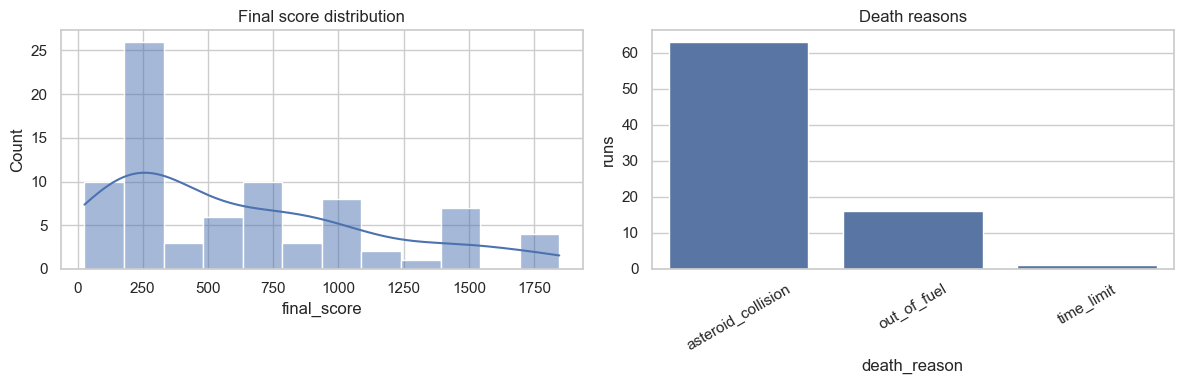

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["result.final_score"], bins=min(12, max(3, len(df) // 3)), kde=True, ax=axes[0])
axes[0].set_title("Final score distribution")
axes[0].set_xlabel("final_score")

if "result.death_reason" in df.columns:
    death_counts = df["result.death_reason"].fillna("unknown").value_counts()
    sns.barplot(x=death_counts.index, y=death_counts.values, ax=axes[1])
    axes[1].set_title("Death reasons")
    axes[1].set_xlabel("death_reason")
    axes[1].set_ylabel("runs")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].axis("off")

plt.tight_layout()

top_cols = [
    "test_number",
    "result.final_score",
    "result.time_alive",
    "result.minerals_gathered",
    "result.death_reason",
    "result.fuel_remaining",
]
display(df[[col for col in top_cols if col in df.columns]].sort_values("result.final_score", ascending=False).head(10))

## 3. Score vs Configuration and Behavior

,corr_with_final_score
behavior.successful_mines,0.907249
result.minerals_gathered,0.884424
behavior.thrust_frames,0.866374
behavior.fuel_used,0.866374
result.time_alive,0.763666
behavior.input_stats.asteroid_velocity_x.count,0.736789
behavior.input_stats.asteroid_velocity_y.count,0.736789
behavior.input_stats.asteroid_relative_velocity_x.count,0.730896
behavior.input_stats.asteroid_relative_velocity_y.count,0.730896
behavior.input_stats.fuel_ratio.count,0.722044


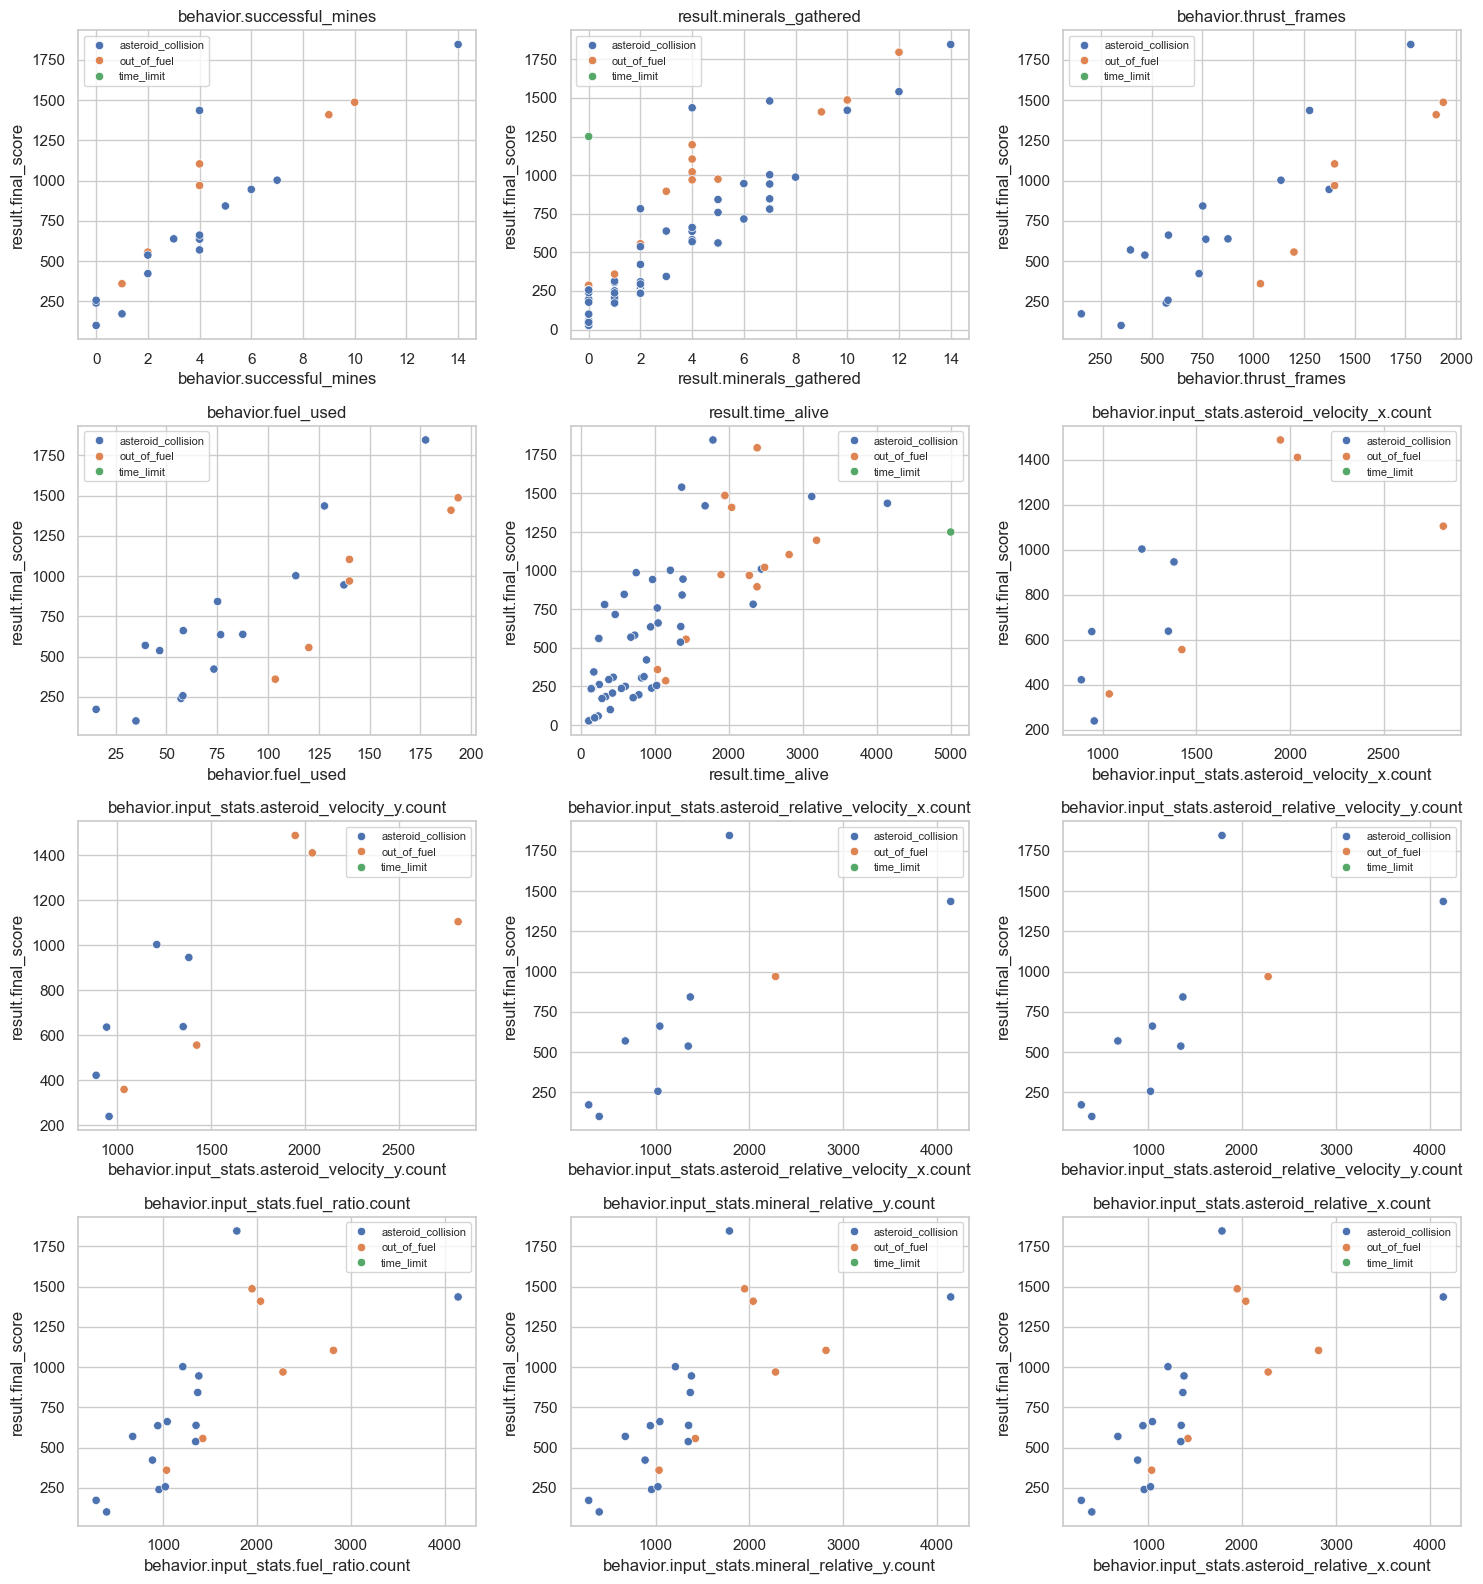

In [7]:
numeric_df = df.select_dtypes(include=["number", "bool"]).copy()
numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")
target = "result.final_score"

fitness_weight_constant_names = {
    "ASTEROID_DANGER_MARGIN",
    "MINERAL_ALIGNMENT_WEIGHT",
    "MINERAL_VELOCITY_WEIGHT",
    "MINERAL_APPROACH_WEIGHT",
    "MINERAL_PROGRESS_WEIGHT",
    "FUEL_EFFICIENCY_WEIGHT",
    "REMAINING_FUEL_WEIGHT",
    "ASTEROID_DANGER_WEIGHT",
    "IDLE_PENALTY_WEIGHT",
    "TIME_WASTED_WEIGHT",
    "ASTEROID_COLLISION_PENALTY",
    "OUT_OF_FUEL_PENALTY",
}
input_feature_prefixes = (
    "behavior.input_stats.",
)
input_feature_config_cols = {
    "artifact_config.DefaultGenome.num_inputs",
    "logged_config.DefaultGenome.num_inputs",
    "training.EXPECTED_INPUTS",
}


def excluded_from_score_correlation(col):
    training_name = col.removeprefix("training.")
    return (
        training_name in fitness_weight_constant_names
        or col.startswith(input_feature_prefixes)
        or col in input_feature_config_cols
    )


candidate_cols = [
    col for col in numeric_df.columns
    if col != target
    and not excluded_from_score_correlation(col)
    and numeric_df[col].nunique(dropna=True) > 1
]
corr = numeric_df[candidate_cols + [target]].corr(numeric_only=True)[target].drop(target).dropna()
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(20)
display(top_corr.to_frame("corr_with_final_score"))

if not top_corr.empty:
    plot_cols = list(top_corr.head(12).index)
    ncols = 3
    nrows = math.ceil(len(plot_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)
    for ax, col in zip(axes.ravel(), plot_cols):
        sns.scatterplot(data=df, x=col, y=target, hue="result.death_reason", ax=ax)
        ax.set_title(col)
        ax.legend(loc="best", fontsize=8)
    for ax in axes.ravel()[len(plot_cols):]:
        ax.axis("off")
    plt.tight_layout()
else:
    print("No varying numeric fields found for score scatter plots.")

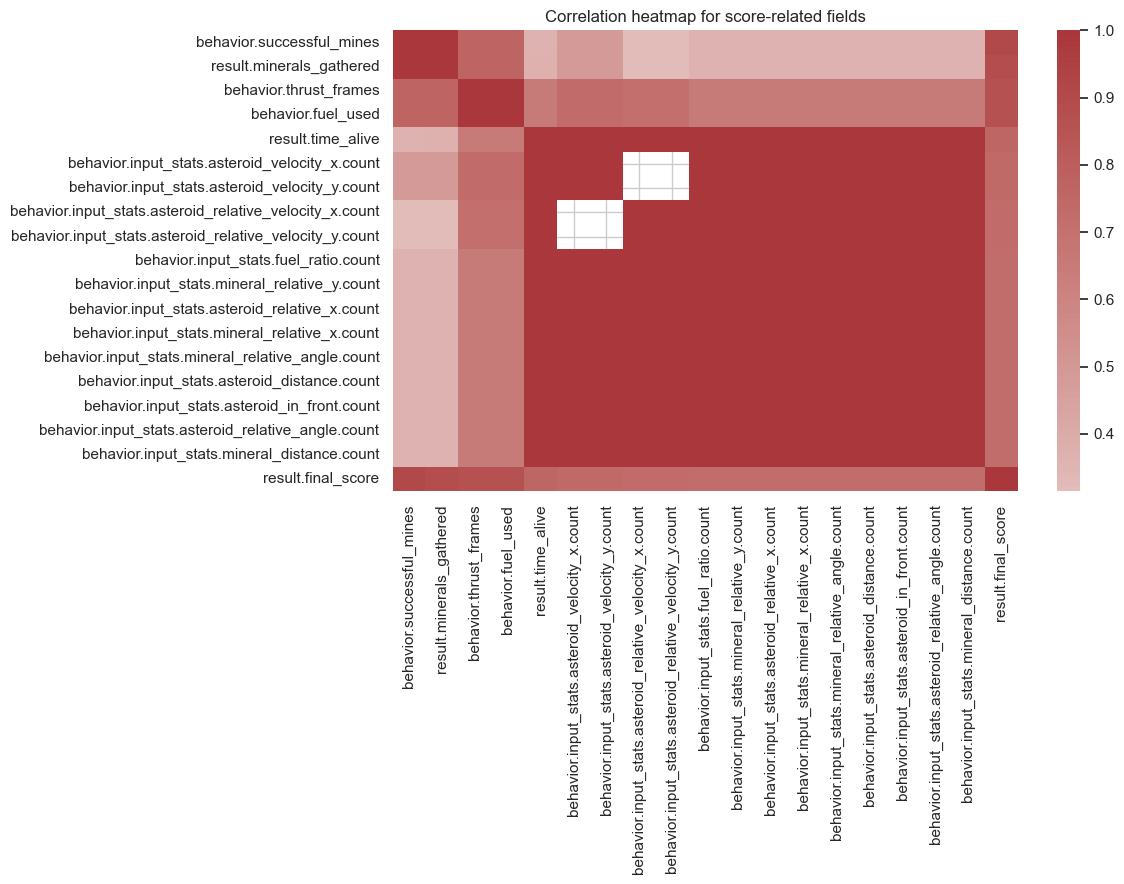

In [8]:
heatmap_cols = list(top_corr.head(18).index) + [target]
if len(heatmap_cols) > 2:
    plt.figure(figsize=(12, 9))
    sns.heatmap(numeric_df[heatmap_cols].corr(), cmap="vlag", center=0, annot=False)
    plt.title("Correlation heatmap for score-related fields")
    plt.tight_layout()

categorical_cols = [
    col for col in df.columns
    if df[col].dtype == "object" and df[col].nunique(dropna=True) > 1 and df[col].nunique(dropna=True) <= 12
]
for col in ["result.death_reason", "artifact_config.DefaultGenome.activation_default", "artifact_config.DefaultGenome.initial_connection"]:
    if col in categorical_cols:
        plt.figure(figsize=(8, 4))
        sns.violinplot(data=df, x=col, y=target, inner="point")
        plt.xticks(rotation=25, ha="right")
        plt.title(f"Final score by {col}")
        plt.tight_layout()

## 4. Fitness Weights and Reward Constants

,test_number,result.final_score,artifact_config.FitnessWeights.minerals,artifact_config.FitnessWeights.alive_time,artifact_config.FitnessWeights.mineral_progress,artifact_config.FitnessWeights.idle_penalty,artifact_config.FitnessWeights.fuel_efficiency,artifact_config.FitnessWeights.asteroid_collision_penalty,artifact_config.FitnessWeights.steering_penalty,artifact_config.FitnessWeights.asteroid_proximity_penalty,...,training.MINERAL_VELOCITY_WEIGHT,training.OUT_OF_FUEL_PENALTY,training.REMAINING_FUEL_WEIGHT,training.TIME_WASTED_WEIGHT,artifact_config.FitnessWeights.mineral_reward,artifact_config.FitnessWeights.alive_time_reward,artifact_config.FitnessWeights.mineral_approach_weight,artifact_config.FitnessWeights.mine_success_bonus,artifact_config.FitnessWeights.asteroid_proximity_dist,artifact_config.FitnessWeights.asteroid_proximity_weight
70,71,969.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,80.0,15.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN
71,72,256.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,80.0,15.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN
72,73,536.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,5.0,1.5,0.05,NaN,NaN,NaN,NaN,NaN,NaN
73,74,569.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,5.0,1.5,0.05,NaN,NaN,NaN,NaN,NaN,NaN
74,75,842.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,5.0,1.5,0.05,NaN,NaN,NaN,NaN,NaN,NaN
75,76,661.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,5.0,1.5,0.05,NaN,NaN,NaN,NaN,NaN,NaN
76,77,1846.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,150.0,0.2,0.03,NaN,NaN,NaN,NaN,NaN,NaN
77,78,171.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,150.0,0.2,0.03,NaN,NaN,NaN,NaN,NaN,NaN
78,79,1436.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,150.0,0.2,0.03,NaN,NaN,NaN,NaN,NaN,NaN
79,80,99.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,150.0,0.2,0.03,NaN,NaN,NaN,NaN,NaN,NaN


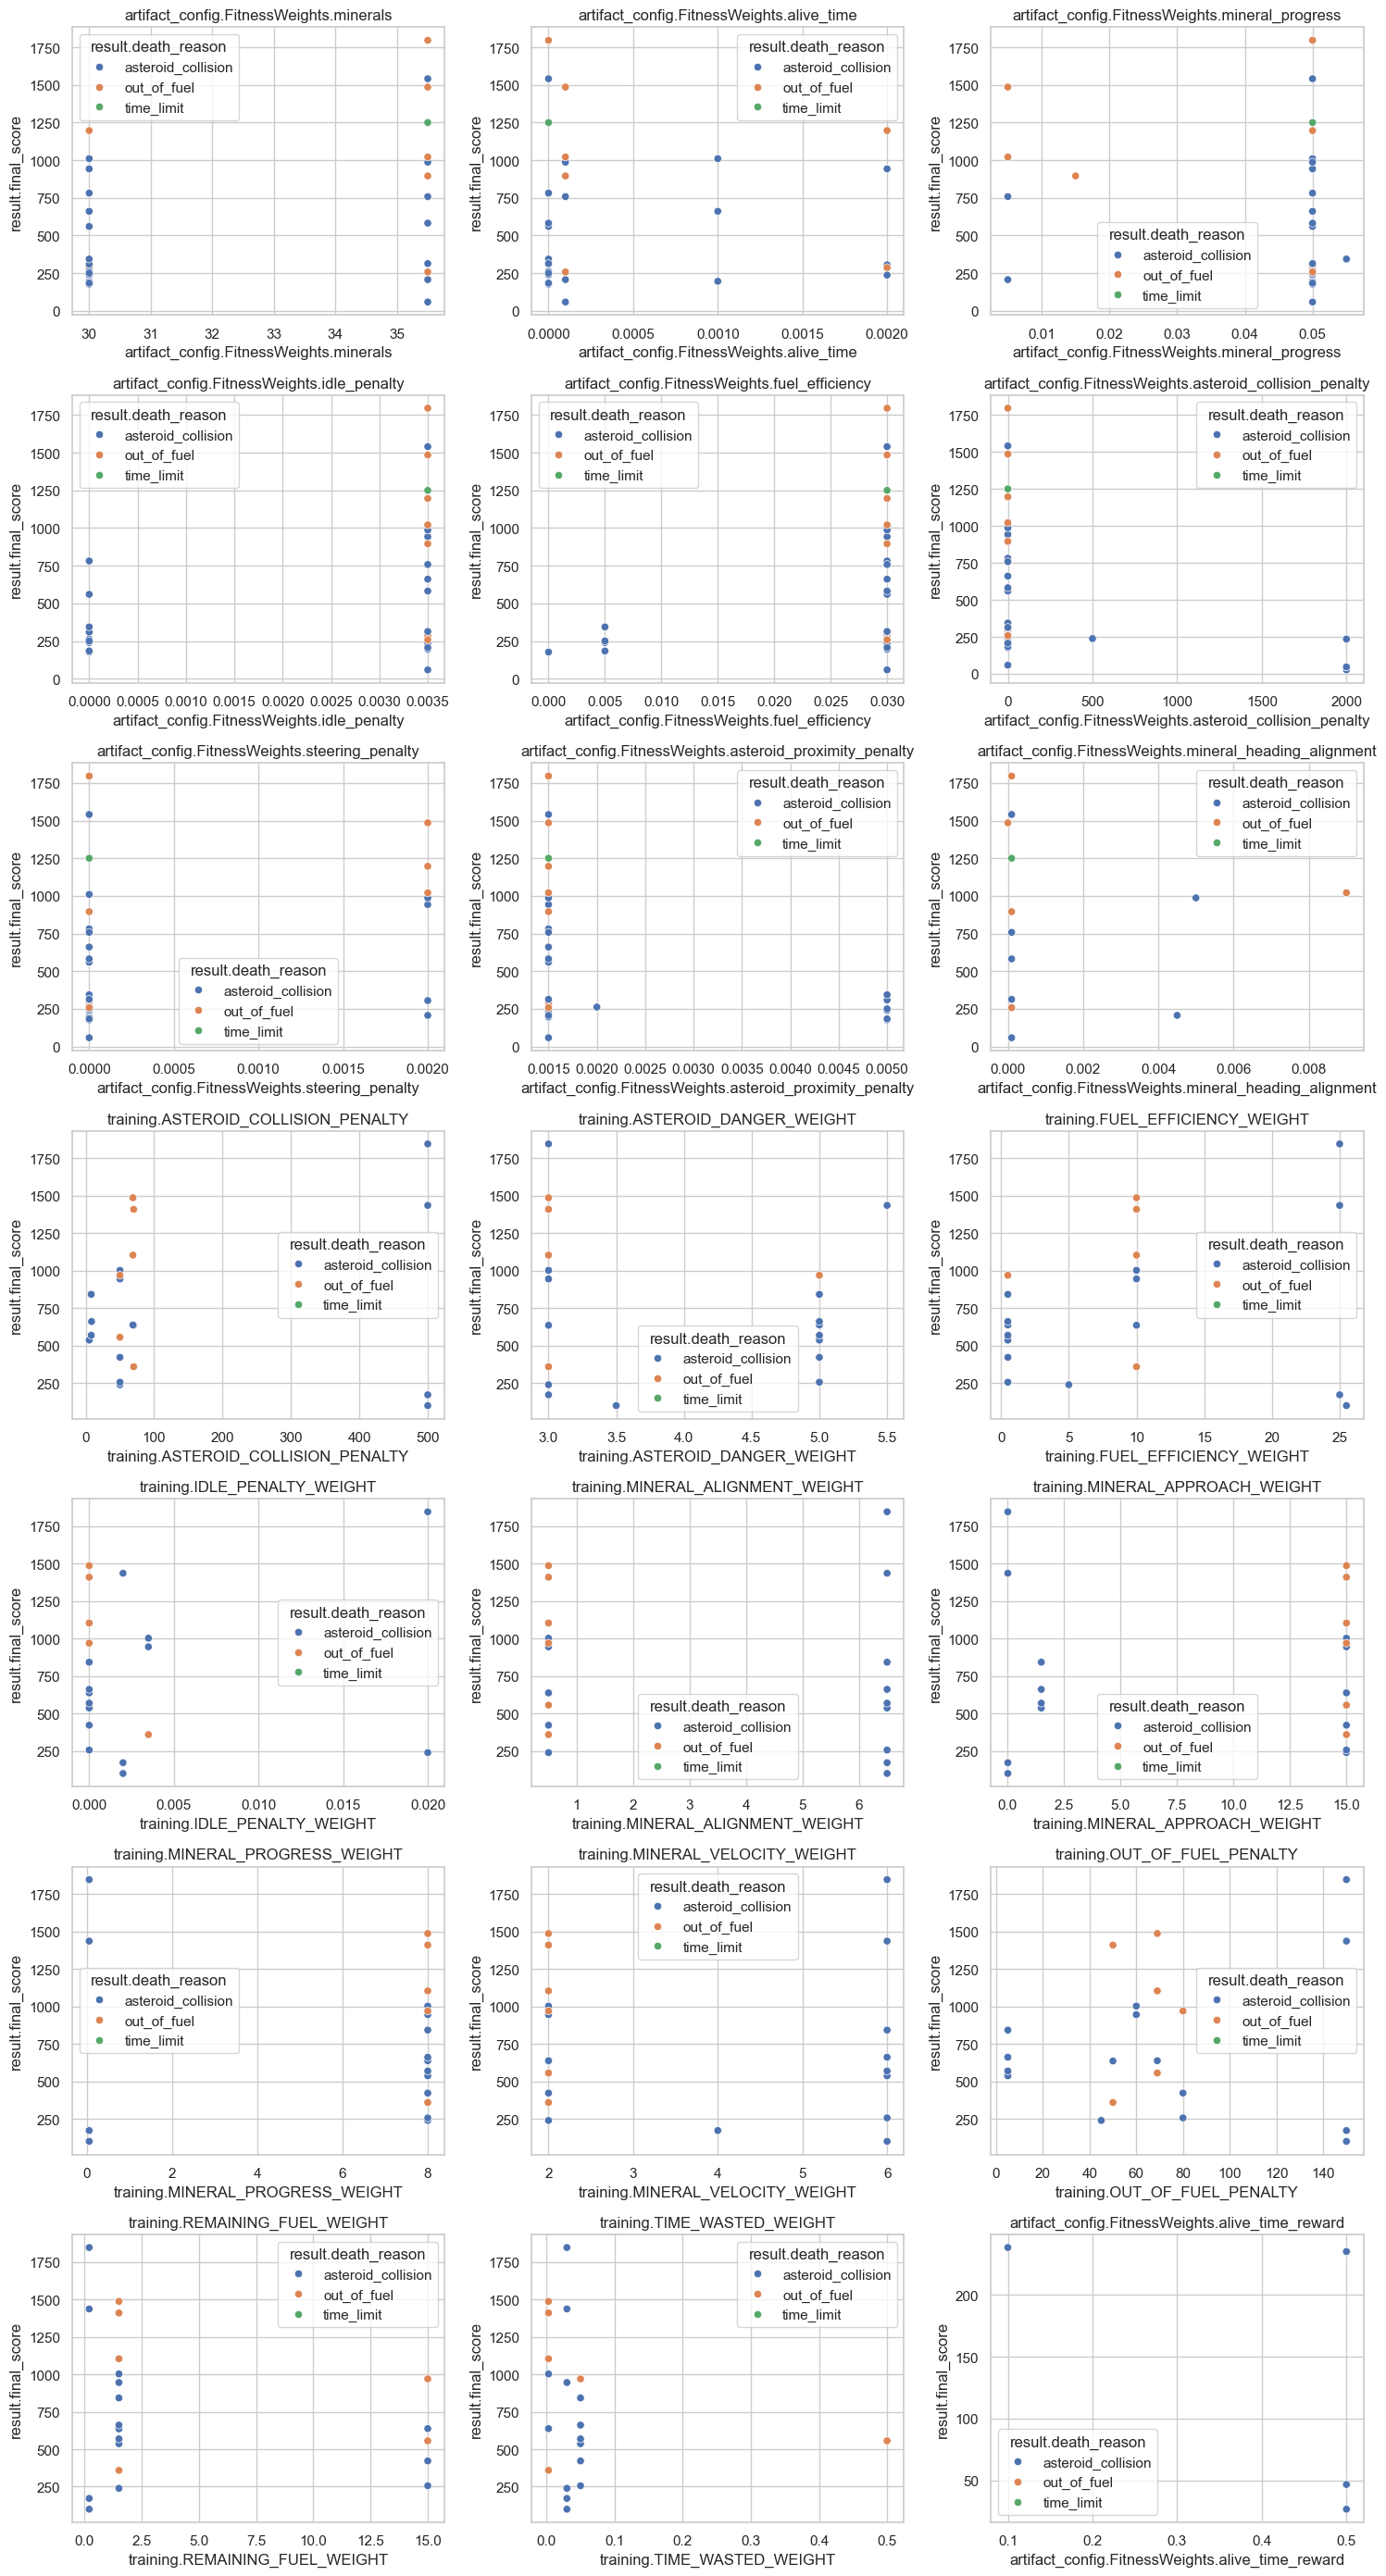

In [9]:
fitness_cols = [
    col for col in numeric_df.columns
    if (
        "FitnessWeights" in col
        or col.startswith("training.") and any(token in col for token in ["WEIGHT", "PENALTY"])
    )
]
varying_fitness_cols = [col for col in fitness_cols if numeric_df[col].nunique(dropna=True) > 1]

if varying_fitness_cols:
    ncols = 3
    nrows = math.ceil(len(varying_fitness_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)
    for ax, col in zip(axes.ravel(), varying_fitness_cols):
        sns.scatterplot(data=df, x=col, y=target, hue="result.death_reason", ax=ax)
        ax.set_title(col)
    for ax in axes.ravel()[len(varying_fitness_cols):]:
        ax.axis("off")
    plt.tight_layout()
else:
    print("No varying fitness-weight or reward-constant fields were found.")
    print("Constant values are still useful context for interpreting behavior, but they cannot explain score differences by themselves.")

context_cols = [col for col in fitness_cols if col in df.columns]
if context_cols:
    display(df[["test_number", target] + context_cols].tail(10))

## 5. DBSCAN Clustering

DBSCAN clusters runs by density. Noise points are labeled `-1`; these are often the interesting outliers to inspect.

DBSCAN feature count: 127


c:\Users\Shira\anaconda3\envs\watch-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Suggested EPS from 75th percentile: 15.204
Adjust EPS in the next cell if the clustering is too coarse or too noisy.


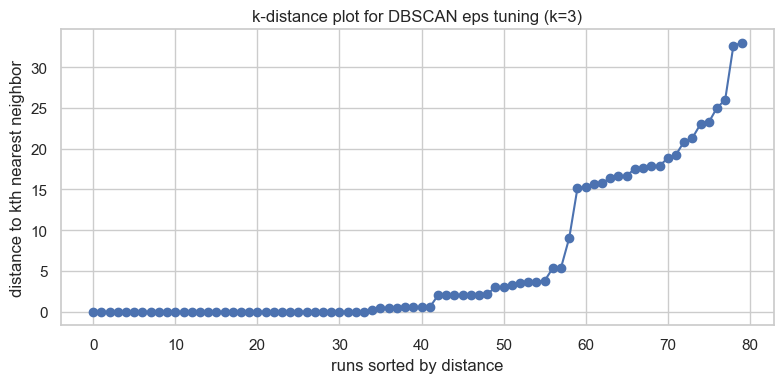

In [10]:
feature_prefixes = (
    "artifact_config.",
    "logged_config.",
    "training.",
    "winner.",
    "behavior.",
)
excluded_for_clustering = {
    "result.final_score",
    "result.time_alive",
    "result.minerals_gathered",
    "result.fuel_remaining",
    "test_number",
    "analysis_schema_version",
}
feature_cols = [
    col for col in numeric_df.columns
    if col.startswith(feature_prefixes)
    and col not in excluded_for_clustering
    and numeric_df[col].nunique(dropna=True) > 1
]

print(f"DBSCAN feature count: {len(feature_cols)}")
feature_df = numeric_df[feature_cols].copy()
feature_df = feature_df.dropna(axis=1, how="all")
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))

MIN_SAMPLES = 3
if len(feature_df) <= MIN_SAMPLES or feature_df.shape[1] == 0:
    raise RuntimeError("Not enough varying numeric config/behavior features for DBSCAN yet")

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbor_distances, _ = neighbors.fit(X).kneighbors(X)
k_distances = np.sort(neighbor_distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances, marker="o")
plt.title(f"k-distance plot for DBSCAN eps tuning (k={MIN_SAMPLES})")
plt.xlabel("runs sorted by distance")
plt.ylabel("distance to kth nearest neighbor")
plt.tight_layout()

EPS = float(np.percentile(k_distances, 75))
print(f"Suggested EPS from 75th percentile: {EPS:.3f}")
print("Adjust EPS in the next cell if the clustering is too coarse or too noisy.")

In [11]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = dbscan.fit_predict(X)
clustered = df.copy()
clustered["dbscan_cluster"] = labels

print("Cluster counts (-1 means DBSCAN noise/outlier):")
display(clustered["dbscan_cluster"].value_counts().sort_index())

summary = clustered.groupby("dbscan_cluster").agg(
    runs=("test_number", "count"),
    mean_score=("result.final_score", "mean"),
    max_score=("result.final_score", "max"),
    mean_minerals=("result.minerals_gathered", "mean"),
    mean_alive=("result.time_alive", "mean"),
    mean_fuel=("result.fuel_remaining", "mean"),
).sort_values("mean_score", ascending=False)
display(summary)

if "result.death_reason" in clustered.columns:
    display(pd.crosstab(clustered["dbscan_cluster"], clustered["result.death_reason"], normalize="index"))

Cluster counts (-1 means DBSCAN noise/outlier):


dbscan_cluster
-1    20
 0    60
Name: count, dtype: int64

,runs,mean_score,max_score,mean_minerals,mean_alive,mean_fuel
dbscan_cluster,,,,,,
-1,20,788.200,1846.5,4.2,1472.8,38.660000
0,60,575.725,1796.0,3.5,902.9,64.033333


result.death_reason,asteroid_collision,out_of_fuel,time_limit
dbscan_cluster,,,
-1,0.700000,0.300000,0.000000
0,0.816667,0.166667,0.016667


,test_number,dbscan_cluster,result.final_score,result.time_alive,result.minerals_gathered,result.death_reason
76,77,-1,1846.50,1786,14,asteroid_collision
42,33,0,1796.00,2384,12,out_of_fuel
40,32,0,1796.00,2384,12,out_of_fuel
39,31,0,1796.00,2384,12,out_of_fuel
37,30,0,1540.75,1363,12,asteroid_collision
57,46,-1,1487.00,1948,10,out_of_fuel
22,22,0,1485.50,1942,10,out_of_fuel
50,39,0,1480.50,3122,7,asteroid_collision
78,79,-1,1436.25,4145,4,asteroid_collision
48,37,0,1420.00,1680,10,asteroid_collision


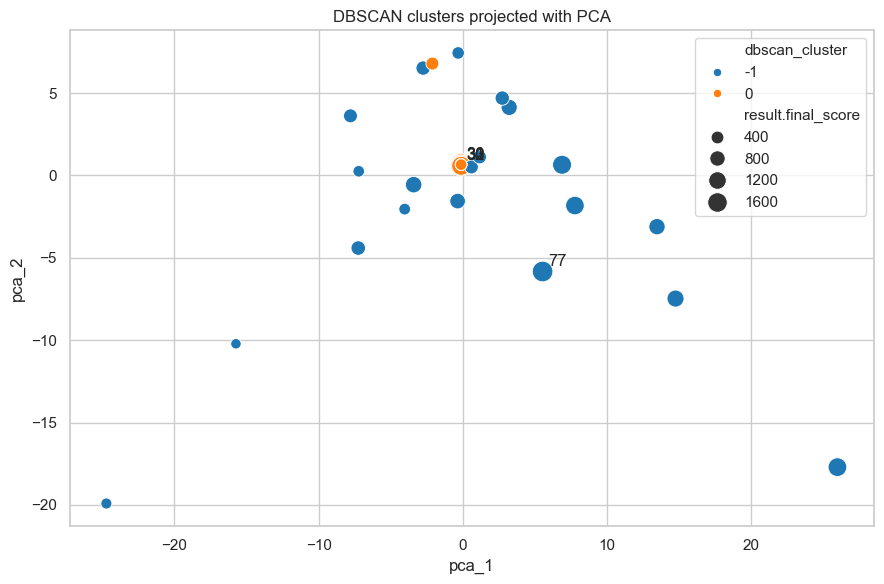

In [12]:
if min(X.shape) >= 3:
    pca = PCA(n_components=3, random_state=0)
    coords = pca.fit_transform(X)
    clustered["pca_1"] = coords[:, 0]
    clustered["pca_2"] = coords[:, 1]
    clustered["pca_3"] = coords[:, 2]

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=clustered,
        x="pca_1",
        y="pca_2",
        hue="dbscan_cluster",
        size="result.final_score",
        palette="tab10",
        sizes=(50, 220),
    )
    for _, row in clustered.nlargest(min(5, len(clustered)), "result.final_score").iterrows():
        plt.annotate(int(row["test_number"]), (row["pca_1"], row["pca_2"]), xytext=(4, 4), textcoords="offset points")
    plt.title("DBSCAN clusters projected with PCA")
    plt.tight_layout()
else:
    print("Skipping PCA plot because fewer than three usable DBSCAN features or samples are available.")


display(clustered.sort_values("result.final_score", ascending=False)[[
    "test_number",
    "dbscan_cluster",
    "result.final_score",
    "result.time_alive",
    "result.minerals_gathered",
    "result.death_reason",
]].head(15))

## 6. Candidate Improvement Notes

Use this table as a prompt for the next training sweep. DBSCAN can reveal repeated behavior/config signatures, but it does not prove causality.

In [13]:
candidate_cols = [
    "test_number",
    "dbscan_cluster",
    "result.final_score",
    "result.time_alive",
    "result.minerals_gathered",
    "result.death_reason",
    "winner.fitness",
    "winner.enabled_connection_count",
    "behavior.thrust_frames",
    "behavior.idle_frames",
    "behavior.mine_attempts",
    "behavior.successful_mines",
    "behavior.fuel_used",
    "behavior.asteroid_danger_exposure",
    "behavior.closest_mineral_distance.mean",
    "behavior.closest_asteroid_clearance.mean",
]
candidate_cols = [col for col in candidate_cols if col in clustered.columns]
display(clustered[candidate_cols].sort_values("result.final_score", ascending=False).head(20))

best_cluster = summary.index[0]
print(f"Best mean-score cluster: {best_cluster}")
print("Next experiment ideas:")
print("- Compare the best cluster against noise points to see which behavior summaries differ most.")
print("- If high-scoring runs have high idle time, increase movement/approach shaping or reduce survival-only rewards.")
print("- If high-scoring runs survive but collect few minerals, strengthen mining/progress rewards and inspect mine_attempts vs successful_mines.")
print("- If outliers score well, replay those winners and use their config as seeds for the next sweep.")

,test_number,dbscan_cluster,result.final_score,result.time_alive,result.minerals_gathered,result.death_reason,winner.fitness,winner.enabled_connection_count,behavior.thrust_frames,behavior.idle_frames,behavior.mine_attempts,behavior.successful_mines,behavior.fuel_used,behavior.asteroid_danger_exposure,behavior.closest_mineral_distance.mean,behavior.closest_asteroid_clearance.mean
76,77,-1,1846.50,1786,14,asteroid_collision,30971.904950,78.0,1776.0,10.0,1717.0,14.0,177.6,14.907073,137.337228,115.400435
42,33,0,1796.00,2384,12,out_of_fuel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,32,0,1796.00,2384,12,out_of_fuel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,31,0,1796.00,2384,12,out_of_fuel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,30,0,1540.75,1363,12,asteroid_collision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,46,-1,1487.00,1948,10,out_of_fuel,84991.603902,65.0,1936.0,12.0,1379.0,10.0,193.6,25.711667,179.832975,117.054683
22,22,0,1485.50,1942,10,out_of_fuel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,39,0,1480.50,3122,7,asteroid_collision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,79,-1,1436.25,4145,4,asteroid_collision,25178.752649,81.0,1278.0,2867.0,2474.0,4.0,127.8,36.452519,180.813800,121.613127
48,37,0,1420.00,1680,10,asteroid_collision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Best mean-score cluster: -1
Next experiment ideas:
- Compare the best cluster against noise points to see which behavior summaries differ most.
- If high-scoring runs have high idle time, increase movement/approach shaping or reduce survival-only rewards.
- If high-scoring runs survive but collect few minerals, strengthen mining/progress rewards and inspect mine_attempts vs successful_mines.
- If outliers score well, replay those winners and use their config as seeds for the next sweep.
